# Goal

* We're going to train model on EMNIST letters and will transfer model to use on digits.
* All convolution layers are going to be freezed and we're going to fine tune only on the output layer.
* Since the number of classes are different we will need to change the output count.

# Libraries

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.model_selection import train_test_split

import torchvision

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

from torchsummary import summary

/tmp/ipython-input-57994026.py:14: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


# Device

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

# Letters

## Data

In [3]:
# download dataset
cdata = torchvision.datasets.EMNIST(root = 'emnist', split = 'letters', download = True)
cdata

Dataset EMNIST
    Number of datapoints: 124800
    Root location: emnist
    Split: Train

In [4]:
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = cdata.data.unsqueeze(1)
print('\nTensor data:')
print(images.shape)

['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print(torch.sum(cdata.targets == 0))

# However, it casuses problems in one-hot encoding
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

## Labels

In [6]:
# therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letter_categories = cdata.classes[1:]

# relabel label to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

print(torch.sum(labels == 0))
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

## Norm

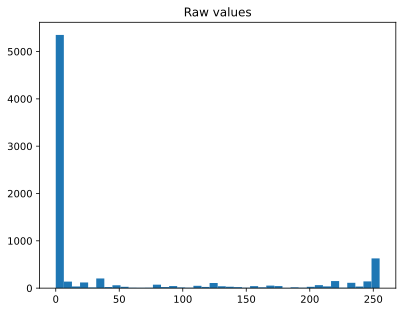

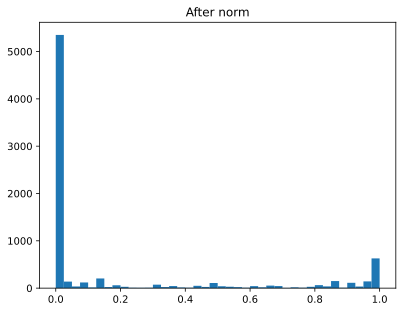

In [7]:
plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('Raw values')
plt.show()

images = images / torch.max(images)

plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('After norm')
plt.show()

## Viz

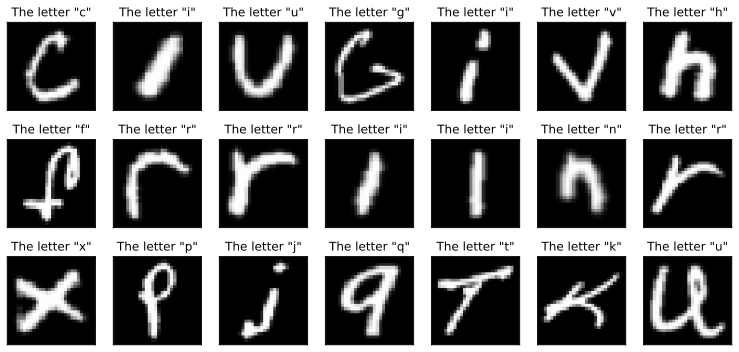

In [8]:
fig, axs = plt.subplots(3, 7, figsize = (13,6))

for i, ax in enumerate(axs.flatten()):

  # pick a random pic
  pic = np.random.randint(images.shape[0])

  # extract the image and its target letter
  I = np.squeeze(images[pic,:,:])
  letter = letter_categories[labels[pic]]

  # viz
  ax.imshow(I.T, cmap = 'gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

## Loaders

In [9]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
l_train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
l_test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

In [10]:
# check size (should be images X channels X width X height)
print(l_train_dataloader.dataset.tensors[0].shape)
print(l_train_dataloader.dataset.tensors[1].shape)

torch.Size([99840, 1, 28, 28])
torch.Size([99840])


In [11]:
labels.unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

## Model

In [18]:
# create a class for the model
def CreateModel(verbose=False):

  class emnistnet(nn.Module):
    def __init__(self,verbose):
      super().__init__()

      # print toggle
      self.print = verbose

      ### -------------- feature map layers -------------- ###
      # first convolution layer
      self.conv1  = nn.Conv2d(1,6,3,padding=1)
      self.bnorm1 = nn.BatchNorm2d(6) # input the number of channels in this layer
      # output size: (28+2*1-3)/1 + 1 = 28/2 = 14 (/2 b/c maxpool)

      # second convolution layer
      self.conv2  = nn.Conv2d(6,6,3,padding=1)
      self.bnorm2 = nn.BatchNorm2d(6) # input the number of channels in this layer
      # output size: (14+2*1-3)/1 + 1 = 14/2 = 7 (/2 b/c maxpool)


      ### -------------- linear decision layers -------------- ###
      self.fc1 = nn.Linear(7*7*6,50)
      self.fc2 = nn.Linear(50,26)

    def forward(self,x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv1(x),2)
      x = F.leaky_relu(self.bnorm1(x))
      if self.print: print(f'First CPR block: {list(x.shape)}')

      # second block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv2(x),2)
      x = F.leaky_relu(self.bnorm2(x))
      if self.print: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      nUnits = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(nUnits))
      if self.print: print(f'Vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      x = self.fc2(x)
      if self.print: print(f'Final output: {list(x.shape)}')

      return x

  # create the model instance
  net = emnistnet(verbose)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [19]:
X, y = next(iter(l_train_dataloader))
net, loss_fn, optimizer = CreateModel(True)
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

Input: [32, 1, 28, 28]
First CPR block: [32, 6, 14, 14]
Second CPR block: [32, 6, 7, 7]
Vectorized: [32, 294]
Final output: [32, 26]


tensor(3.3027, grad_fn=<NllLossBackward0>)

In [20]:
summary(net.to(device), (1, 28, 28))

Input: [2, 1, 28, 28]
First CPR block: [2, 6, 14, 14]
Second CPR block: [2, 6, 7, 7]
Vectorized: [2, 294]
Final output: [2, 26]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]              60
       BatchNorm2d-2            [-1, 6, 14, 14]              12
            Conv2d-3            [-1, 6, 14, 14]             330
       BatchNorm2d-4              [-1, 6, 7, 7]              12
            Linear-5                   [-1, 50]          14,750
            Linear-6                   [-1, 26]           1,326
Total params: 16,490
Trainable params: 16,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.06
Estimated Total Size (MB): 0.12
----------------------------------------------------------------


## Train

In [21]:
# create a new model
l_net, loss_fn, optimizer = CreateModel(verbose = False)

In [22]:
def RunModel(net, train_dataloader, test_dataloader, epochs, verbose):

  net = net.to(device)

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # batch loss and acc
      preds = torch.argmax(y_hat, dim=1)
      batch_accs.append((preds == y).float().mean().item())
      batch_losses.append(loss.item())


    # losses
    train_accs[epoch] = 100 * np.mean(batch_accs)
    train_losses[epoch] = np.mean(batch_losses)

    # test acc
    X, y = next(iter(test_dataloader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad():
      y_hat = net(X)
      loss = loss_fn(y_hat, y)
      preds = torch.argmax(y_hat, dim=1)

    test_losses[epoch] = loss.item()
    test_accs[epoch] = 100 * (preds == y).float().mean().item()


    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [23]:
l_train_losses, l_test_losses, l_train_accs, l_test_accs, l_net = RunModel(l_net,
                                                                           l_train_dataloader,
                                                                           l_test_dataloader,
                                                                           epochs = 10, verbose = False)

Epoch 0 Train Loss: 0.6041, Test Loss: 0.3785, Train Acc: 81.8319, Test Acc: 87.7444
Epoch 1 Train Loss: 0.3317, Test Loss: 0.3050, Train Acc: 89.2608, Test Acc: 90.3526
Epoch 2 Train Loss: 0.2893, Test Loss: 0.2858, Train Acc: 90.5158, Test Acc: 90.8974
Epoch 3 Train Loss: 0.2675, Test Loss: 0.2740, Train Acc: 91.1558, Test Acc: 91.1218
Epoch 4 Train Loss: 0.2490, Test Loss: 0.2695, Train Acc: 91.6817, Test Acc: 91.2220
Epoch 5 Train Loss: 0.2384, Test Loss: 0.2717, Train Acc: 91.9531, Test Acc: 91.2180
Epoch 6 Train Loss: 0.2283, Test Loss: 0.2591, Train Acc: 92.2736, Test Acc: 91.9431
Epoch 7 Train Loss: 0.2211, Test Loss: 0.2695, Train Acc: 92.5220, Test Acc: 91.4663
Epoch 8 Train Loss: 0.2136, Test Loss: 0.2562, Train Acc: 92.7384, Test Acc: 91.6827
Epoch 9 Train Loss: 0.2084, Test Loss: 0.2597, Train Acc: 92.8766, Test Acc: 91.9071


## Plots

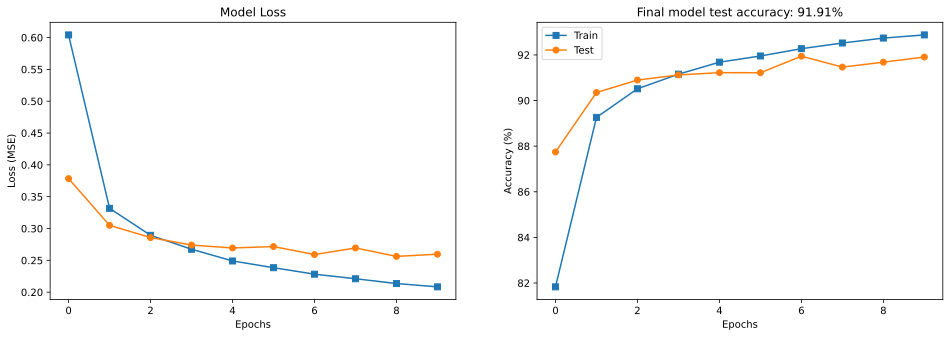

In [24]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(l_train_losses.cpu().detach(), 's-', label = 'Train')
ax[0].plot(l_test_losses.cpu().detach(), 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(l_train_accs.cpu().detach(), 's-', label = 'Train')
ax[1].plot(l_test_accs.cpu().detach(), 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {l_test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

# Digits

## Data

In [25]:
digits_data = torchvision.datasets.EMNIST(root = 'emnist', split = 'digits', download = True)
digits_data

Dataset EMNIST
    Number of datapoints: 240000
    Root location: emnist
    Split: Train

In [26]:
print(digits_data.classes)
print(str(len(digits_data.classes)) + ' classes')

print('\nData size:')
print(digits_data.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
d_images = digits_data.data.unsqueeze(1)
print('\nTensor data:')
print(d_images.shape)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10 classes

Data size:
torch.Size([240000, 28, 28])

Tensor data:
torch.Size([240000, 1, 28, 28])


In [27]:
# brief aside: class 'N/A' doesn't exist in the data.
print(torch.sum(digits_data.targets == 0))

# However, it casuses problems in one-hot encoding
torch.unique(digits_data.targets)

tensor(24000)


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
digits_data.class_to_idx

{'0': 0,
 '1': 1,
 '2': 2,
 '3': 3,
 '4': 4,
 '5': 5,
 '6': 6,
 '7': 7,
 '8': 8,
 '9': 9}

## Labels

In [29]:
digits_categories = digits_data.classes

digits_labels = copy.deepcopy(digits_data.targets)
print(digits_labels.shape)

print(torch.sum(digits_labels == 0))
torch.unique(digits_labels)

torch.Size([240000])
tensor(24000)


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## Norm

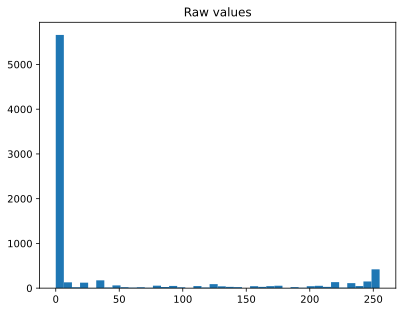

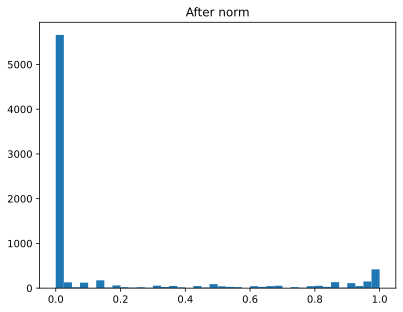

In [30]:
plt.hist(d_images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('Raw values')
plt.show()

d_images = d_images / torch.max(d_images)

plt.hist(d_images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('After norm')
plt.show()

## Viz

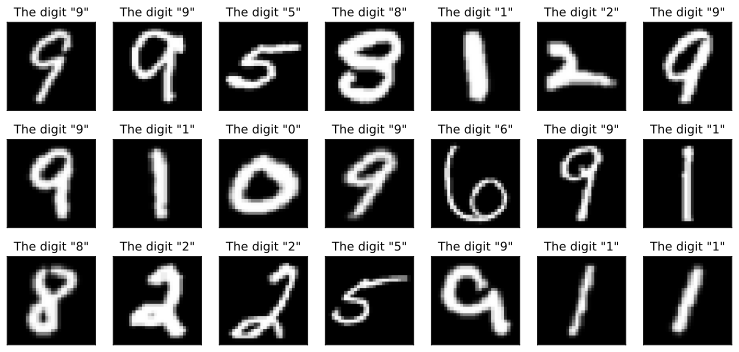

In [31]:
fig, axs = plt.subplots(3, 7, figsize = (13,6))

for i, ax in enumerate(axs.flatten()):

  # pick a random pic
  pic = np.random.randint(images.shape[0])

  # extract the image and its target letter
  I = np.squeeze(d_images[pic,:,:])
  letter = digits_categories[digits_labels[pic]]

  # viz
  ax.imshow(I.T, cmap = 'gray')
  ax.set_title('The digit "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

## Loaders

In [32]:
train_data, test_data, train_labels, test_labels = train_test_split(d_images, digits_labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
d_train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
d_test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

In [33]:
# check size (should be images X channels X width X height)
print(d_train_dataloader.dataset.tensors[0].shape)
print(d_train_dataloader.dataset.tensors[1].shape)

torch.Size([192000, 1, 28, 28])
torch.Size([192000])


In [34]:
digits_labels.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## One Epoch from Scratch

In [35]:
# create a new model
d_net, loss_fn, optimizer = CreateModel(verbose = False)

In [36]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [37]:
# adjust number of output units
d_net.fc2 = nn.Linear(50,10)

In [38]:
d_train_losses, d_test_losses, d_train_accs, d_test_accs, d_net = RunModel(d_net,
                                                                           d_train_dataloader,
                                                                           d_test_dataloader,
                                                                           epochs = 1,
                                                                           verbose = False)

Epoch 0 Train Loss: 0.0997, Test Loss: 0.0502, Train Acc: 97.3172, Test Acc: 98.5167


In [39]:
X, y = next(iter(d_test_dataloader))

d_net = d_net.to(device)
X = X.to(device)
y = y.to(device)

y_hat = d_net(X)
loss = loss_fn(y_hat, y)
preds = torch.argmax(y_hat, dim=1)
acc = ((preds == y).float().mean().item())
print(f'Acc: {acc:.3f}')

Acc: 0.985


Accuracy of model trained for 1 epoch is 98.5% which is absurdly good. We prboably won't improve the model with transfer learning.

## Transfer Learning from Letters

In [40]:
# create a new model
d_net, loss_fn, optimizer = CreateModel(verbose = False)

We need to copy all layers' params but two last fc layers since both depend on shape of the out_neurons.

In [41]:
# then replace all the weights in TARGET model from SOURCE model
for target,source in zip(d_net.named_parameters(),l_net.named_parameters()):
  target[1].data = copy.deepcopy( source[1].data )

# adjust number of output units
d_net.fc2 = nn.Linear(50,10)

# freeze convolution and batch-norm layers
for p in d_net.named_parameters():
  if ('conv' in p[0]) or ('bnorm' in p[0]):
    p[1].requires_grad = False

In [42]:
d_train_losses, d_test_losses, d_train_accs, d_test_accs, d_net = RunModel(d_net,
                                                                           d_train_dataloader,
                                                                           d_test_dataloader,
                                                                           epochs = 1,
                                                                           verbose = False)

Epoch 0 Train Loss: 0.1180, Test Loss: 0.0471, Train Acc: 96.7266, Test Acc: 98.6125


In [43]:
X, y = next(iter(d_test_dataloader))

d_net = d_net.to(device)
X = X.to(device)
y = y.to(device)

y_hat = d_net(X)
loss = loss_fn(y_hat, y)
preds = torch.argmax(y_hat, dim=1)
acc = ((preds == y).float().mean().item())
print(f'Acc: {acc:.3f}')

Acc: 0.986


We got a little bit better accuracy which can be a noise.